<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/09_EDA_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9주차 실습: EDA — 생체신호 시각화

## 학습 목표
- 탐색적 데이터 분석(EDA)의 개념과 중요성을 이해할 수 있다
- Matplotlib/Seaborn으로 시계열 꺾은선 그래프를 그릴 수 있다
- 연령대별 혈압 박스플롯(Boxplot)을 생성하고 해석할 수 있다

---

## 오늘의 핵심 개념: EDA란 무엇인가?

> 의사가 환자를 처음 만났을 때 바로 수술하지 않고 문진·청진·촉진을 통해 환자의 상태를 전반적으로 파악하듯 EDA는 데이터를 모델링하기 전 전체적인 패턴·이상값·분포를 탐색하는 과정

### 병원정보시스템과 EDA
- **9주차 연계:** 병원정보시스템에 축적된 환자 데이터를 효과적으로 분석하려면 EDA가 첫 단계
- **임상적 EDA 활용 예시:**
  - 계절별 입원 환자 수 변화 시각화
  - 연령대·성별에 따른 혈압 분포 비교
  - 투약 후 활력징후 변화 추이 모니터링

### 주요 시각화 도구
- **시계열 그래프(Line Plot):** 시간에 따른 변화 추이
- **박스플롯(Boxplot):** 분포 요약 (중앙값, 사분위수, 이상값)
- **산점도(Scatter Plot):** 두 변수 간 상관관계

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib
from datetime import datetime, timedelta

## Part 1. 시계열 데이터 생성 — 30일 생체신호

In [2]:
np.random.seed(42)

# 30일치 날짜 생성
start_date = datetime(2026, 2, 1)
dates = [start_date + timedelta(days=i) for i in range(30)]

# 활력징후 시뮬레이션 (환자 1명, 30일)
# 체온: 초기 발열 후 정상화
temp_base  = [38.5, 39.0, 38.8, 38.4, 38.1, 37.9, 37.7, 37.5, 37.4,
              37.3, 37.1, 37.0, 36.9, 36.8, 37.0, 36.9, 36.8, 36.7,
              36.8, 36.9, 36.8, 37.0, 36.9, 36.8, 37.1, 36.9, 36.8,
              36.9, 37.0, 36.8]
temp = [t + np.random.normal(0, 0.1) for t in temp_base]

# 수축기 혈압
sbp = 140 + np.random.normal(0, 8, 30)
sbp[:5] = sbp[:5] + 15  # 초기 고혈압 상태

# 심박수
hr  = 88 + np.random.normal(0, 5, 30)
hr[:7] = hr[:7] + 12

df_vital = pd.DataFrame({
    '날짜':   dates,
    '체온':   np.round(temp, 1),
    '수축기혈압': np.round(sbp, 0).astype(int),
    '심박수':  np.round(hr, 0).astype(int)
})

print('30일 생체신호 데이터 생성 완료!')
df_vital.head(10)

30일 생체신호 데이터 생성 완료!


,날짜,체온,수축기혈압,심박수
0,2026-02-01,38.5,150,98
1,2026-02-02,39.0,170,99
2,2026-02-03,38.9,155,94
3,2026-02-04,38.6,147,94
4,2026-02-05,38.1,162,104
5,2026-02-06,37.9,130,107
6,2026-02-07,37.9,142,100
7,2026-02-08,37.6,124,93
8,2026-02-09,37.4,129,90
9,2026-02-10,37.4,142,85


## Part 2. 시계열 꺾은선 그래프

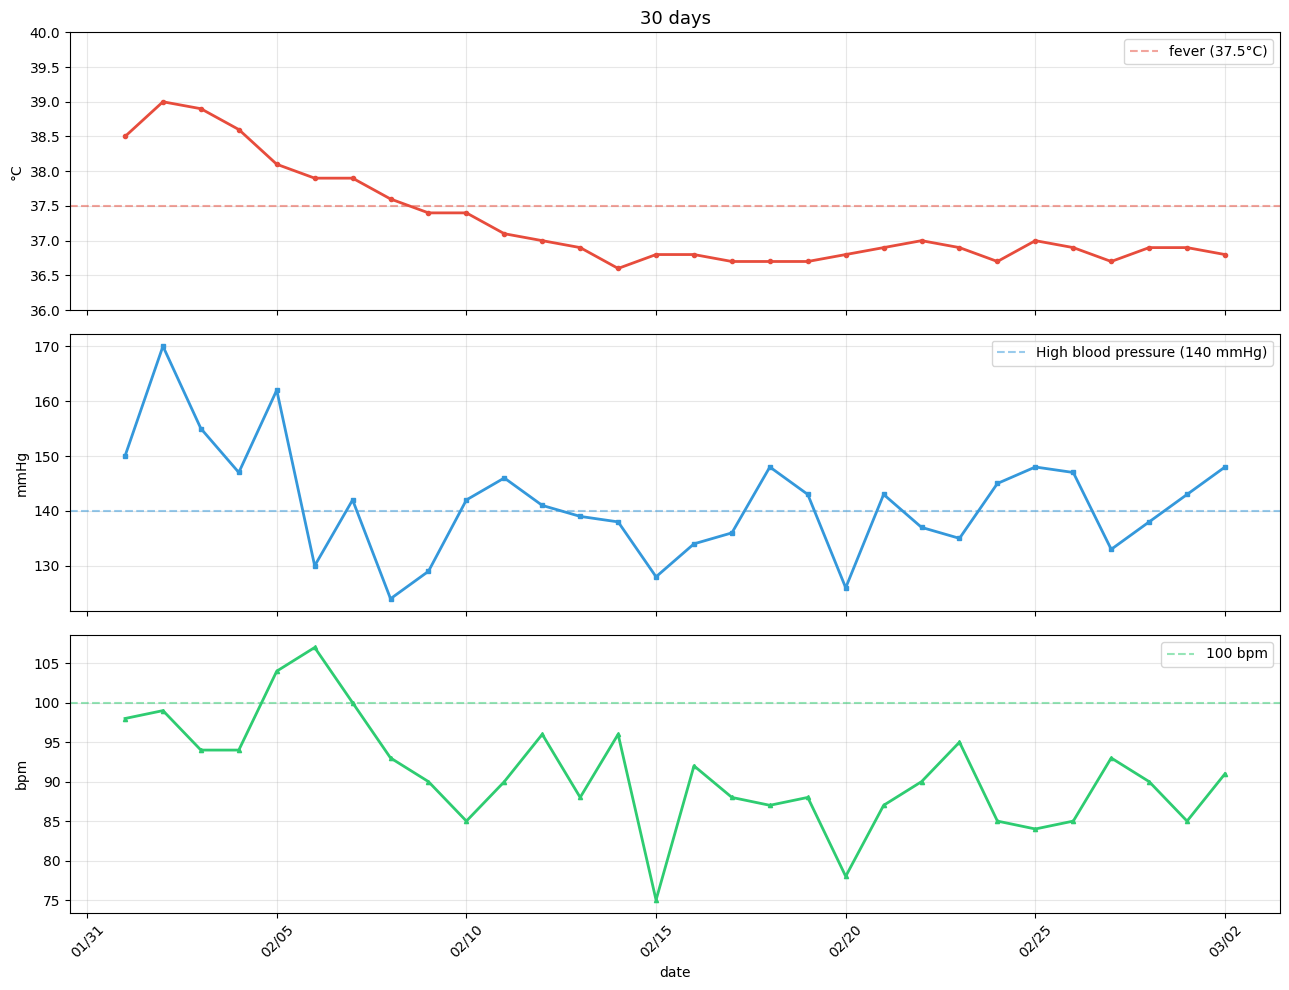

시계열 그래프: 초기 발열·고혈압 상태에서 점진적으로 정상화되는 패턴 확인!


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# 체온
axes[0].plot(df_vital['날짜'], df_vital['체온'], color='#e74c3c', linewidth=2, marker='o', markersize=3)
axes[0].axhline(y=37.5, color='#e74c3c', linestyle='--', alpha=0.5, label='fever (37.5°C)')
axes[0].set_ylabel('°C')
axes[0].set_title('30 days', fontsize=13)
axes[0].legend()
axes[0].set_ylim(36, 40)

# 수축기혈압
axes[1].plot(df_vital['날짜'], df_vital['수축기혈압'], color='#3498db', linewidth=2, marker='s', markersize=3)
axes[1].axhline(y=140, color='#3498db', linestyle='--', alpha=0.5, label='High blood pressure (140 mmHg)')
axes[1].set_ylabel('mmHg')
axes[1].legend()

# 심박수
axes[2].plot(df_vital['날짜'], df_vital['심박수'], color='#2ecc71', linewidth=2, marker='^', markersize=3)
axes[2].axhline(y=100, color='#2ecc71', linestyle='--', alpha=0.5, label='100 bpm')
axes[2].set_ylabel('bpm')
axes[2].set_xlabel('date')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('시계열 그래프: 초기 발열·고혈압 상태에서 점진적으로 정상화되는 패턴 확인!')

## Part 3. 연령대별 혈압 박스플롯

In [4]:
np.random.seed(42)
n_per_group = 50

# 연령대별 수축기혈압 데이터 (연령대가 높을수록 혈압이 높은 경향)
age_groups = ['20s', '30s', '40s', '50s', '60s', '7s']
bp_means   = [115,   120,   128,   138,   148,   155]
bp_stds    = [10,    11,    13,    15,    16,    18]

records = []
for age_g, mean, std in zip(age_groups, bp_means, bp_stds):
    sbp_vals = np.random.normal(mean, std, n_per_group)
    for v in sbp_vals:
        records.append({'연령대': age_g, '수축기혈압': round(v)})

df_bp = pd.DataFrame(records)

print('연령대별 혈압 데이터 생성 완료!')
print(df_bp.groupby('연령대')['수축기혈압'].describe())

연령대별 혈압 데이터 생성 완료!
     count    mean        std    min     25%    50%     75%    max
연령대                                                               
20s   50.0  112.74   9.380418   95.0  106.50  113.0  118.00  134.0
30s   50.0  120.24   9.624713   91.0  114.25  120.5  126.75  137.0
40s   50.0  127.52  13.160299  103.0  116.50  128.5  134.75  160.0
50s   50.0  139.20  13.385951  115.0  127.00  141.0  146.50  179.0
60s   50.0  150.36  17.437656  116.0  138.00  151.0  159.00  210.0
7s    50.0  154.60  19.431722   97.0  143.25  155.5  168.50  193.0


/tmp/ipykernel_5823/69975773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5823/69975773.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5823/69975773.py:24: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5823/69975773.py:24: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5823/69975773.py:24: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50672 (\N

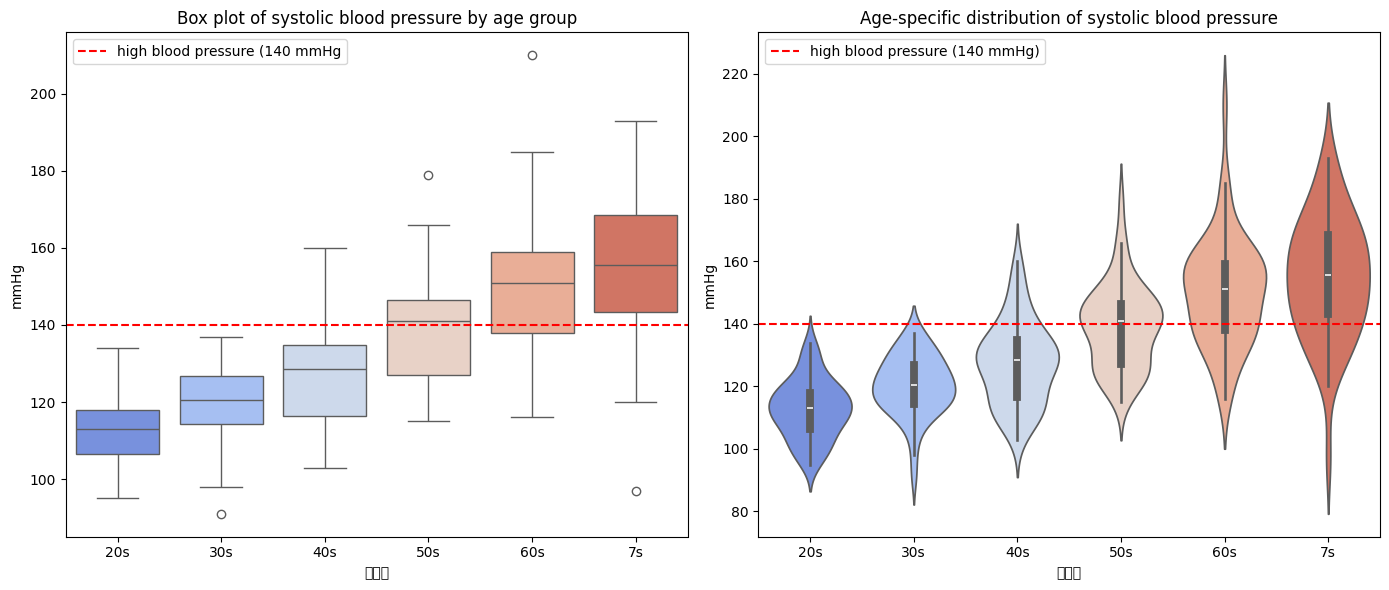

In [5]:
# 박스플롯 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 박스플롯
sns.boxplot(
    data=df_bp, x='연령대', y='수축기혈압',
    order=age_groups, palette='coolwarm', ax=axes[0]
)
axes[0].axhline(y=140, color='red', linestyle='--', label='high blood pressure (140 mmHg')
axes[0].set_title('Box plot of systolic blood pressure by age group', fontsize=12)
axes[0].set_ylabel('mmHg')
axes[0].legend()

# 바이올린 플롯 (분포 형태도 함께 확인)
sns.violinplot(
    data=df_bp, x='연령대', y='수축기혈압',
    order=age_groups, palette='coolwarm', ax=axes[1]
)
axes[1].axhline(y=140, color='red', linestyle='--', label='high blood pressure (140 mmHg)')
axes[1].set_title('Age-specific distribution of systolic blood pressure', fontsize=12)
axes[1].set_ylabel('mmHg')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 4. 체온이 37.5도 이상인 날 계산

In [6]:
# 발열(체온 >= 37.5) 일수 계산
fever_days = (df_vital['체온'] >= 37.5).sum()
normal_days = len(df_vital) - fever_days

print(f'총 측정 일수: {len(df_vital)}일')
print(f'발열(≥37.5°C) 일수: {fever_days}일')
print(f'정상 체온 일수: {normal_days}일')

fever_detail = df_vital[df_vital['체온'] >= 37.5][['날짜', '체온']]
print('\n발열 상세 기록:')
for _, row in fever_detail.iterrows():
    print(f'  {row["날짜"].strftime("%m/%d")}: {row["체온"]}°C')

총 측정 일수: 30일
발열(≥37.5°C) 일수: 8일
정상 체온 일수: 22일

발열 상세 기록:
  02/01: 38.5°C
  02/02: 39.0°C
  02/03: 38.9°C
  02/04: 38.6°C
  02/05: 38.1°C
  02/06: 37.9°C
  02/07: 37.9°C
  02/08: 37.6°C


---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** 생성된 30일치 생체신호 데이터에서 체온이 37.5°C 이상인 날(발열 일수)은 총 몇 일일까요?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = int(fever_days)
print(f'Answer: {canvas_answer}')